c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with M

전체 평균 실루엣 계수: 0.3180
PCA 설명 변수 비율: [0.33690046 0.26230645]
   Gender  Age  Annual Income (k$)  Spending Score (1-100)  cluster  \
0       1   19                  15                      39        1   
1       1   21                  15                      81        1   
2       0   20                  16                       6        4   
3       0   23                  16                      77        2   
4       0   31                  17                      40        4   

   silhouette_coeff     pca_x     pca_y  
0          0.181239 -0.406383 -0.520714  
1          0.272620 -1.427673 -0.367310  
2          0.086516  0.050761 -1.894068  
3          0.286695 -1.694513 -1.631908  
4          0.103216 -0.313108 -1.810483  


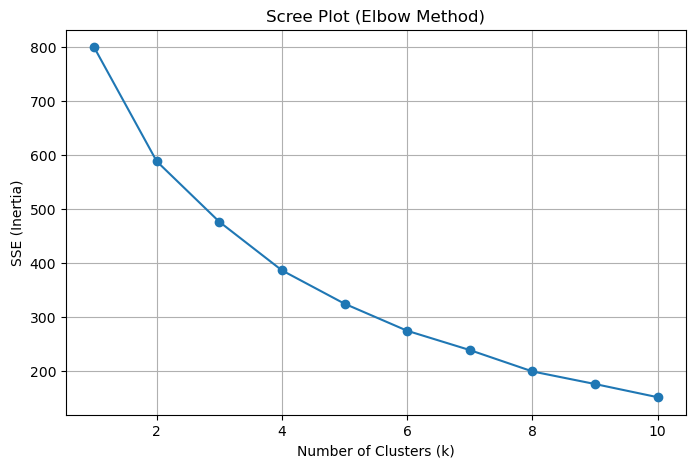

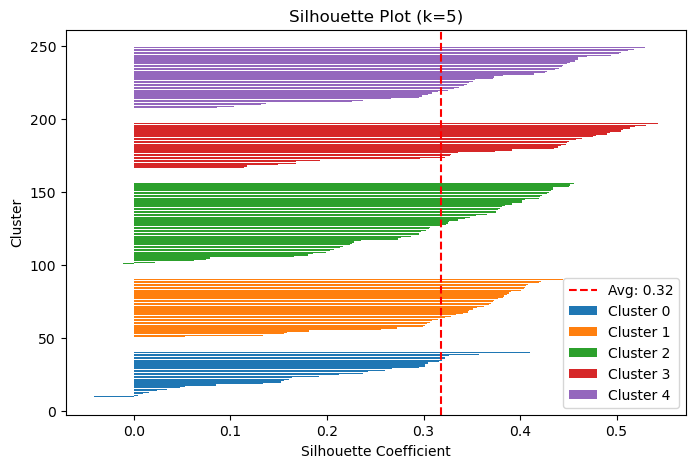

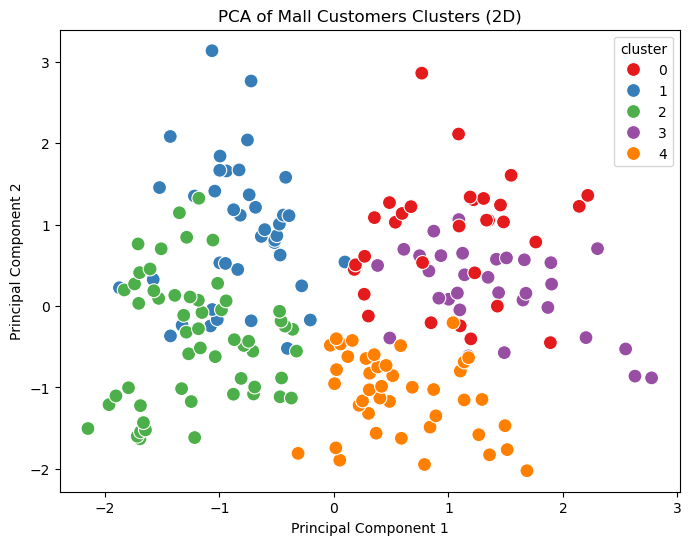

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

# 1. 데이터 로드 및 전처리
df = pd.read_csv('./data/Mall_Customers.csv')

# ID 제거
df_processed = df.drop(columns=['CustomerID'])

# Gender 인코딩 (LabelEncoder 사용)
le = LabelEncoder()
df_processed['Gender'] = le.fit_transform(df_processed['Gender'])

# 피처 스케일링 (StandardScaler)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_processed)
df_scaled_df = pd.DataFrame(df_scaled, columns=df_processed.columns)

# 2. k값 선택을 위한 스크리 차트 (Elbow Method)
sse_values = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, random_state=0, n_init=10)
    kmeans.fit(df_scaled)
    sse_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, sse_values, marker='o')
plt.title('Scree Plot (Elbow Method)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.grid(True)
plt.savefig('scree_plot.png')

# 3. K-Means 군집화 (k=5 선택)
n_clusters = 5
km = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, random_state=0, n_init=10)
clusters = km.fit_predict(df_scaled)
df_processed['cluster'] = clusters

# 4. 군집 평가 : 실루엣 계수 산출 및 시각화
avg_score = silhouette_score(df_scaled, clusters)
score_samples = silhouette_samples(df_scaled, clusters)
df_processed['silhouette_coeff'] = score_samples

plt.figure(figsize=(8, 5))
y_lower = 10
for i in range(n_clusters):
    cluster_i_values = score_samples[clusters == i]
    cluster_i_values.sort()
    y_upper = y_lower + len(cluster_i_values)
    plt.barh(range(y_lower, y_upper), cluster_i_values, label=f'Cluster {i}')
    y_lower = y_upper + 10 

plt.axvline(avg_score, color='red', linestyle='--', label=f'Avg: {avg_score:.2f}')
plt.title(f'Silhouette Plot (k={n_clusters})')
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Cluster')
plt.legend()
plt.savefig('silhouette_plot.png')

# 5. PCA 차원 축소 및 시각화
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_scaled)
df_processed['pca_x'] = pca_features[:, 0]
df_processed['pca_y'] = pca_features[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x='pca_x', y='pca_y', hue='cluster', palette='Set1', data=df_processed, s=100)
plt.title('PCA of Mall Customers Clusters (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('pca_cluster_plot.png')

print(f"전체 평균 실루엣 계수: {avg_score:.4f}")
print("PCA 설명 변수 비율:", pca.explained_variance_ratio_)
print(df_processed.head())

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


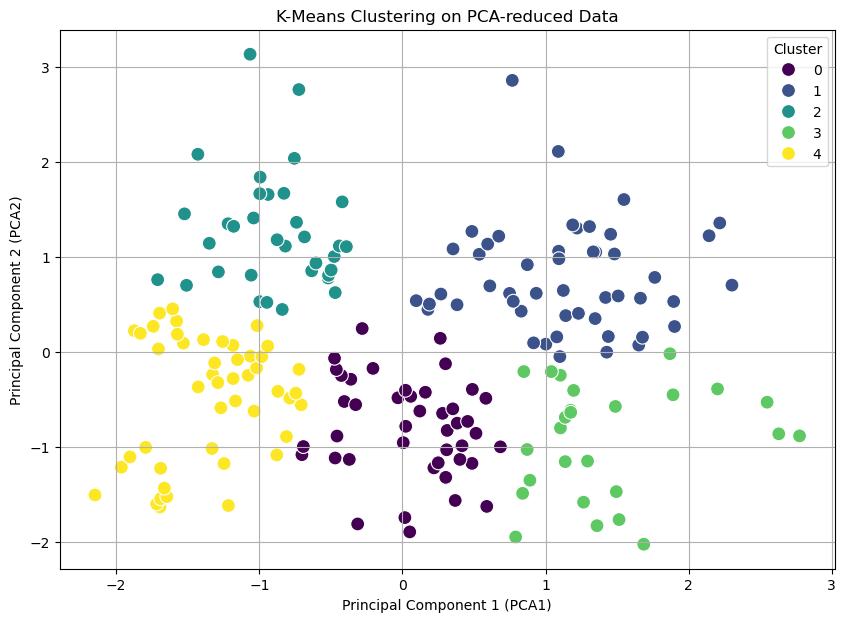

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# 1. CustomerID 제거 및 성별 인코딩
df = pd.read_csv('./data/Mall_Customers.csv')
df_processed = df.drop(columns=['CustomerID'])
le = LabelEncoder()
df_processed['Gender'] = le.fit_transform(df_processed['Gender']) # Female: 0, Male: 1

# 2. StandardScaler로 x 스케일링
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_processed)

# 3. PCA : 2개의 주성분으로 압축
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# 4. KMEANS 클러스터링 (PCA 축소 데이터를 기반으로 수행)
# (K=5는 데이터의 특성을 고려하여 임의 설정, 필요시 Elbow Method로 재조정 가능)
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, random_state=0, n_init=10)
clusters = kmeans.fit_predict(df_pca)

# 결과 저장을 위한 데이터프레임 생성
df_final = pd.DataFrame(df_pca, columns=['PCA1', 'PCA2'])
df_final['cluster'] = clusters

# 5. KMeans 클러스터링 결과 시각화
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', palette='viridis', data=df_final, s=100)
plt.title('K-Means Clustering on PCA-reduced Data')
plt.xlabel('Principal Component 1 (PCA1)')
plt.ylabel('Principal Component 2 (PCA2)')
plt.legend(title='Cluster')
plt.grid(True)